In [ ]:
import sys
import os
import cv2
import numpy as np
import time
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import random

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) # ->Exercise3

sys.path.append(parent_dir)
from data.load_cifar import retrieve_all_cifar, unpickle

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  
# 1. CONFIGURATION & CLASS DEFINITIONS
#  
IMG_SIZE = (64, 64)       # Standardize size (SIFT needs larger images than 32x32)
VOCAB_SIZE = 100          # Visual Words for BoW
SEED = 42                 # Reproducibility

# GTSRB Classes
GTSRB_CLASSES = {
    0: 'Speed 20', 1: 'Speed 30', 2: 'Speed 50', 3: 'Speed 60', 4: 'Speed 70', 
    5: 'Speed 80', 6: 'End Speed 80', 7: 'Speed 100', 8: 'Speed 120', 9: 'No passing', 
    10: 'No passing >3.5t', 11: 'Right-of-way', 12: 'Priority road', 13: 'Yield', 
    14: 'Stop', 15: 'No vehicles', 16: 'Veh >3.5t prohib', 17: 'No entry', 
    18: 'General caution', 19: 'Curve left', 20: 'Curve right', 21: 'Double curve', 
    22: 'Bumpy road', 23: 'Slippery', 24: 'Narrows right', 25: 'Road work', 
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children', 29: 'Bicycles', 
    30: 'Ice/Snow', 31: 'Wild animals', 32: 'End limits', 33: 'Turn right', 
    34: 'Turn left', 35: 'Ahead only', 36: 'Straight/Right', 37: 'Straight/Left', 
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout', 41: 'End no passing', 
    42: 'End no pass >3.5t'
}

# CIFAR Classes
CIFAR_CLASSES = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

#  
# 2. DATA LOADERS
#  
def load_gtsrb_data(base_path, mode="train", sample_fraction=1.0):
    """Loads GTSRB images and labels from disk.

    Args:
        base_path: Path to the dataset root folder.
        mode: The loading mode. "train" expects class subfolders; "test" expects flat images and a CSV.
        sample_fraction: Fraction of data to load (0.0 to 1.0) for faster debugging.

    Returns:
        A tuple containing (images, labels) as numpy arrays.
    """
    print(f"[INFO] Loading GTSRB ({mode}) from {base_path}...")
    images, labels = [], []
    
    # 1. Check if path exists
    if not os.path.exists(base_path):
        print(f"[ERROR] Path not found: {base_path}")
        return np.array([]), np.array([])

    # 2. LOGIC FOR TRAINING DATA (Subfolders)
    if mode == "train":
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
        for class_id, class_name in enumerate(classes):
            class_dir = os.path.join(base_path, class_name)
            img_files = [f for f in os.listdir(class_dir) if f.endswith(('.ppm', '.png'))]
            
            # Apply Sampling
            if sample_fraction < 1.0:
                count = int(len(img_files) * sample_fraction)
                img_files = random.sample(img_files, max(1, count))

            for img_file in img_files:
                img = cv2.imread(os.path.join(class_dir, img_file))
                if img is not None:
                    images.append(cv2.resize(img, IMG_SIZE))
                    labels.append(class_id)

    # 3. LOGIC FOR TEST DATA (Flat folder + CSV Answer Key)
    elif mode == "test":
        # Search for CSV
        csv_file = None
        search_paths = [base_path, os.path.dirname(base_path)]
        for p in search_paths:
            for f in os.listdir(p):
                if f.endswith(".csv") and "test" in f.lower():
                    csv_file = os.path.join(p, f)
                    break
            if csv_file: break
        
        if csv_file is None:
            print("\n[CRITICAL ERROR] No CSV file found in Test folder!")
            print(f"Please copy 'GT-final_test.csv' into: {base_path}")
            return np.array([]), np.array([])
        
        print(f"[INFO] Parsing Answer Key: {os.path.basename(csv_file)}")
        
        try:
            df = pd.read_csv(csv_file, sep=';')
            if 'ClassId' not in df.columns:
                print("[ERROR] CSV is missing 'ClassId' column. Check if it's the correct GT file.")
                return np.array([]), np.array([])
        except:
            print("[ERROR] Could not parse CSV. Check delimiter.")
            return np.array([]), np.array([])

        if sample_fraction < 1.0:
            df = df.sample(frac=sample_fraction, random_state=SEED)

        for index, row in df.iterrows():
            img_name = row['Filename']
            class_id = row['ClassId']
            img_path = os.path.join(base_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                images.append(cv2.resize(img, IMG_SIZE))
                labels.append(class_id)
    
    # 4. SAFETY CATCH (If mode is typo'd)
    else:
        print(f"[ERROR] Unknown mode '{mode}'. Use 'train' or 'test'.")
        return np.array([]), np.array([])

    # 5. FINAL RETURN (MUST BE OUTSIDE IF/ELSE BLOCKS)
    return np.array(images), np.array(labels)


def load_cifar_adapter(sample_fraction=1.0):
    """Loads and preprocesses CIFAR-10 data.

    Args:
        sample_fraction: Fraction of data to load (0.0 to 1.0).

    Returns:
        A tuple containing (X_processed, y) as numpy arrays.
    """
    print(f"[INFO] Loading CIFAR-10 via custom loader...")
    # Calls your imported function
    raw_data = retrieve_all_cifar("train") 
    
    X_flat = np.array(raw_data['data'])
    y = np.array(raw_data['labels'])
    
    # Sampling
    if sample_fraction < 1.0:
        indices = np.random.choice(len(y), int(len(y)*sample_fraction), replace=False)
        X_flat = X_flat[indices]
        y = y[indices]

    # Reshape (N, 3072) -> (N, 3, 32, 32) -> (N, 32, 32, 3)
    X_images = X_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    # Convert RGB(CIFAR) -> BGR(OpenCV) and Resize
    X_processed = []
    for img in X_images:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        X_processed.append(cv2.resize(img_bgr, IMG_SIZE))
        
    return np.array(X_processed), y


    
def evaluate_and_report(model, X_test, y_test, class_names, title="Model Evaluation"):
    """Standardized evaluation printing metrics and plotting Confusion Matrix.

    Args:
        model: The trained scikit-learn model (or GridSearchCV).
        X_test: Test features.
        y_test: True test labels.
        class_names: Dictionary mapping label indices to class names.
        title: Title for the evaluation report.
    """
    print(f"\n{'='*60}\nFINAL REPORT: {title}\n{'='*60}")
    y_pred = model.predict(X_test)
    
    # 1. Overall Accuracy
    overall_acc = accuracy_score(y_test, y_pred)
    print(f"Overall Accuracy: {overall_acc:.4f}\n")
    
    cm = confusion_matrix(y_test, y_pred)
    row_sums = cm.sum(axis=1)
    
    # 2. Per-Class Accuracy
    per_class_acc = np.divide(cm.diagonal(), row_sums, out=np.zeros_like(cm.diagonal(), dtype=float), where=row_sums!=0)
    print("Per-class Accuracy:")
    for idx, acc in enumerate(per_class_acc):
        name = class_names.get(idx, str(idx))
        print(f"   {name:>20}: {acc:.3f}")

    # 3. Classification Report (Precision, Recall, F1)
    print("\nClassification Report:")
    present_labels = sorted(list(set(y_test)))
    present_names = [class_names.get(i, str(i)) for i in present_labels]
    print(classification_report(y_test, y_pred, target_names=present_names, digits=3))

    # 4. Confusion Matrix Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"Confusion Matrix – {title}")
    plt.tight_layout()
    plt.show()


#  
# 4. FEATURE EXTRACTION
#  
def extract_color_histograms(images, bins=(8, 8, 8)):
    """Extracts flattened HSV color histograms for a set of images.

    Args:
        images: Array of input images (BGR format).
        bins: Tuple representing the number of bins per channel (H, S, V).

    Returns:
        Numpy array of shape (N_images, flattened_hist_size).
    """
    features = []
    for img in images:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        features.append(hist.flatten())
    return np.array(features)


class VisualBagOfWords:
    """Implements a Visual Bag-of-Words model using SIFT and K-Means."""

    def __init__(self, k=100):
        """Initialize the BoW model.

        Args:
            k: The size of the vocabulary (number of clusters).
        """
        self.k = k
        self.kmeans = None
        self.sift = cv2.SIFT_create()

    def fit(self, images):
        """Builds the visual vocabulary from the input images.

        Args:
            images: Array of training images.
        """

        print("[INFO] BoW: Building vocabulary...")
        descriptor_list = []
        sample_indices = np.random.choice(len(images), min(len(images), 1000), replace=False)
        for idx in sample_indices:
            gray = cv2.cvtColor(images[idx], cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            if des is not None: descriptor_list.append(des)
        
        if descriptor_list:
            all_descriptors = np.vstack(descriptor_list)
            self.kmeans = KMeans(n_clusters=self.k, random_state=SEED, n_init=10).fit(all_descriptors)
            print("[INFO] BoW: Vocabulary created.")
        else:
            print("[WARN] No descriptors found.")

    def transform(self, images):
        """Converts images into Bag-of-Words histograms using the learned vocabulary.

        Args:
            images: Array of images to transform.

        Returns:
            Numpy array of shape (N_images, k).
        """
        histograms = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            hist = np.zeros(self.k)
            if des is not None and self.kmeans:
                preds = self.kmeans.predict(des)
                for p in preds: hist[p] += 1
            if np.sum(hist) > 0: hist /= np.sum(hist)
            histograms.append(hist)
        return np.array(histograms)


def predict_from_path(image_path, models_dict, bow_model, class_names):
    """Predicts the class of a single image file using all trained models.

    Args:
        image_path: Path to the query image.
        models_dict: Dictionary of trained models (key=name, value=model).
        bow_model: The trained VisualBagOfWords instance.
        class_names: Dictionary mapping label indices to class names.
    """
    if not os.path.exists(image_path): return
    img = cv2.imread(image_path)
    if img is None: return

    # --- CENTER CROP (Fix aspect ratio for internet images) ---
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    img_cropped = img[start_y:start_y+min_dim, start_x:start_x+min_dim]
    img_resized = cv2.resize(img_cropped, IMG_SIZE)
    
    print(f"\n{'='*40}\nPREDICTION: {image_path}\n{'='*40}")
    plt.figure(figsize=(3,3))
    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Processed Input")
    plt.show()

    feat_hist = extract_color_histograms([img_resized])
    feat_bow = bow_model.transform([img_resized])

    results = {}
    if 'Hist_SVM' in models_dict: results['Hist+SVM'] = (models_dict['Hist_SVM'], feat_hist)
    if 'Hist_RF' in models_dict: results['Hist+RF'] = (models_dict['Hist_RF'], feat_hist)
    if 'SIFT_SVM' in models_dict: results['SIFT+SVM'] = (models_dict['SIFT_SVM'], feat_bow)
    if 'SIFT_RF' in models_dict: results['SIFT+RF'] = (models_dict['SIFT_RF'], feat_bow)

    for name, (model, feat) in results.items():
        try:
            est = model.best_estimator_ if hasattr(model, "best_estimator_") else model
            probs = est.predict_proba(feat)[0]
            top5 = np.argsort(probs)[::-1][:5]
            print(f"\n--- {name} ---")
            for rank, idx in enumerate(top5, 1):
                print(f"   {rank}. {class_names.get(idx, idx):<20} : {probs[idx]*100:.2f}%")
        except: pass



In [ ]:
# Visualization:

def visualize_sift_keypoints(image):
    """Plots the specific SIFT image you asked for."""
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp = sift.detect(gray, None)
    img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Features Detected: {len(kp)}")
    plt.axis('off')
    plt.show()

def plot_grid_results(grid_search, title="Grid Search Results"):
    """Plots the validation curve from a fitted GridSearchCV object.

    Args:
        grid_search: The fitted GridSearchCV object.
        title: The title for the plot.
    """
    results = grid_search.cv_results_
    params = grid_search.param_grid
    param_names = list(params.keys())
    means = results['mean_test_score']
    
    print(f"[PLOT] Generating plot for: {param_names}")

    # CASE 1: 1D Plot (Only one parameter tuned, e.g., 'C')
    if len(param_names) == 1:
        param = param_names[0]
        values = params[param]
        
        plt.figure(figsize=(8, 5))
        plt.plot(values, means, marker='o', linewidth=2, color='navy')
        plt.title(f"{title}\nEffect of {param}")
        plt.xlabel(param)
        plt.ylabel("CV Accuracy")
        plt.grid(True, alpha=0.3)
        if param in ['C', 'gamma']: plt.xscale('log')
        plt.show()

    # CASE 2: 2D Heatmap (Two parameters tuned, e.g., 'C' and 'gamma')
    elif len(param_names) == 2:
        param1, param2 = param_names[0], param_names[1]
        vals1, vals2 = params[param1], params[param2]
        
        # Reshape mean scores to match the grid shape
        # Note: We must ensure the order matches. GridSearchCV usually flattens in order.
        scores_matrix = means.reshape(len(vals1), len(vals2))
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(scores_matrix, annot=True, fmt=".3f", cmap="viridis",
                    xticklabels=vals2, yticklabels=vals1)
        plt.title(f"{title}\n{param1} vs {param2}")
        plt.xlabel(param2)
        plt.ylabel(param1)
        plt.show()
    
    else:
        print("[WARN] Too many parameters to plot automatically (max 2).")

# Plotting related methods
def plot_samples(images, labels, class_names, num_samples=5):
    """Displays random samples from the dataset.

    Args:
        images: Array of images.
        labels: Array of label indices.
        class_names: Dictionary mapping label indices to class names.
        num_samples: Number of random samples to display.
    """
    plt.figure(figsize=(15, 3))
    indices = np.random.choice(len(images), min(len(images), num_samples), replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        label_text = class_names.get(labels[idx], f"Class {labels[idx]}")
        plt.title(label_text, fontsize=9)
        plt.axis('off')
    plt.suptitle("Random Dataset Samples")
    plt.show()

def plot_class_distribution(labels, class_names):
    """Plots a bar chart showing the frequency of each class.

    Args:
        labels: Array of label indices.
        class_names: Dictionary mapping label indices to class names.
        title: Title of the plot.
    """
    plt.figure(figsize=(12, 5))
    unique, counts = np.unique(labels, return_counts=True)
    names = [class_names.get(i, str(i)) for i in unique]
    sns.barplot(x=names, y=counts, palette="viridis")
    plt.title("Class Distribution")
    plt.xticks(rotation=90 if len(unique) > 10 else 45)
    plt.tight_layout()
    plt.show()

def plot_rgb_histograms_dynamic(images, labels, class_names):
    """Plots RGB color histograms for two random classes to visualize feature separability.

    Args:
        images: Array of images.
        labels: Array of label indices.
        class_names: Dictionary mapping label indices to class names.
    """
    unique_classes = np.unique(labels)
    if len(unique_classes) < 2: return
    target_classes = np.random.choice(unique_classes, 2, replace=False)
    
    plt.figure(figsize=(12, 5))
    colors = ['b', 'g', 'r'] # OpenCV is BGR
    
    for i, cls in enumerate(target_classes):
        indices = np.where(labels == cls)[0]
        class_imgs = images[indices]
        plt.subplot(1, 2, i+1)
        name = class_names.get(cls, f"Class {cls}")
        plt.title(f"Avg RGB: {name}")
        
        for ch_idx, col in enumerate(colors):
            avg_hist = np.mean([cv2.calcHist([img], [ch_idx], None, [256], [0, 256]) 
                                for img in class_imgs], axis=0)
            plt.plot(avg_hist, color=col, label=f"Ch {ch_idx}")
        plt.legend()
        plt.grid(alpha=0.3)
    plt.suptitle("RGB Analysis (Random 2 Classes)")
    plt.show()

def visualize_sift_keypoints(image):
    """Visualizes SIFT keypoints on a single image.

    Args:
        image: The input image.
    """
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp = sift.detect(gray, None)
    img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Features Detected: {len(kp)}")
    plt.axis('off')
    plt.show()

def plot_confusion_matrix_dynamic(y_test, y_pred, model_name, class_names):
    """Plots a confusion matrix for model predictions.

    Args:
        y_test: True labels.
        y_pred: Predicted labels.
        model_name: Name of the model (for the title).
        class_names: Dictionary mapping label indices to class names.
    """
    cm = confusion_matrix(y_test, y_pred)
    unique_labels = sorted(list(set(y_test) | set(y_pred)))
    tick_labels = [class_names.get(i, str(i)) for i in unique_labels]
    
    plt.figure(figsize=(10, 8) if len(unique_labels) < 15 else (14, 14))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

[INFO] Loading GTSRB (train) from C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images...
[INFO] Loading GTSRB (test) from C:\Users\lenar\Downloads\GTSRB_Final_Test_Images\GTSRB\Final_Test\Images...
[INFO] Parsing Answer Key: GT-final_test.csv

[INFO] Dataset Stats:
   Training Images: 7841
   Testing Images:  2526

[INFO] 1. Plotting Data Samples...


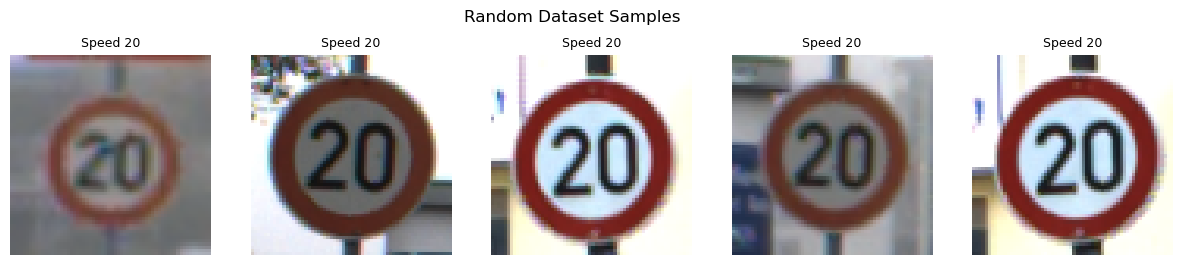


[INFO] 2. Plotting Class Distribution (Train)...


C:\Users\lenar\AppData\Local\Temp\ipykernel_22068\266443401.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=counts, palette="viridis")


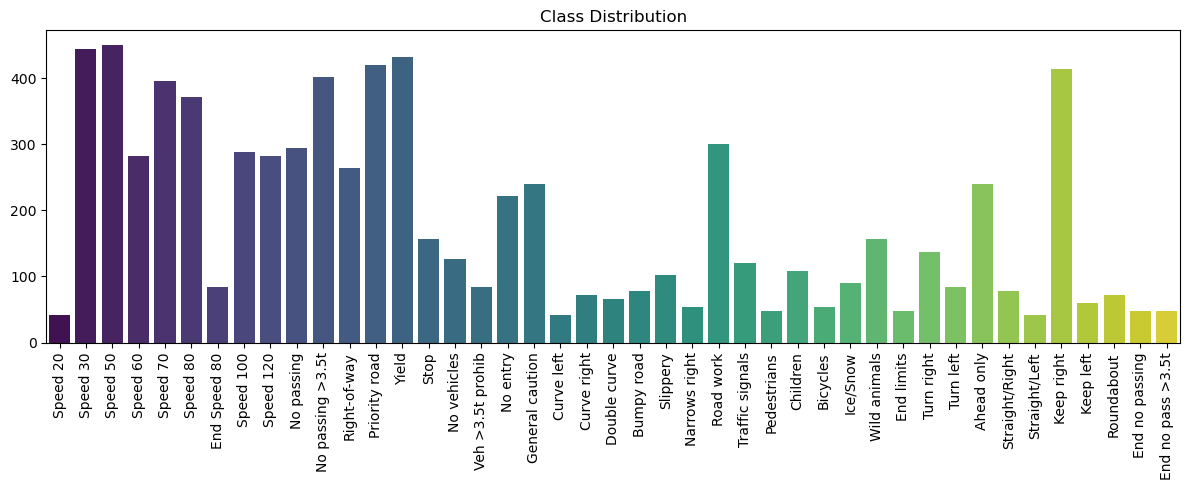


[INFO] 3. Plotting RGB Histograms...


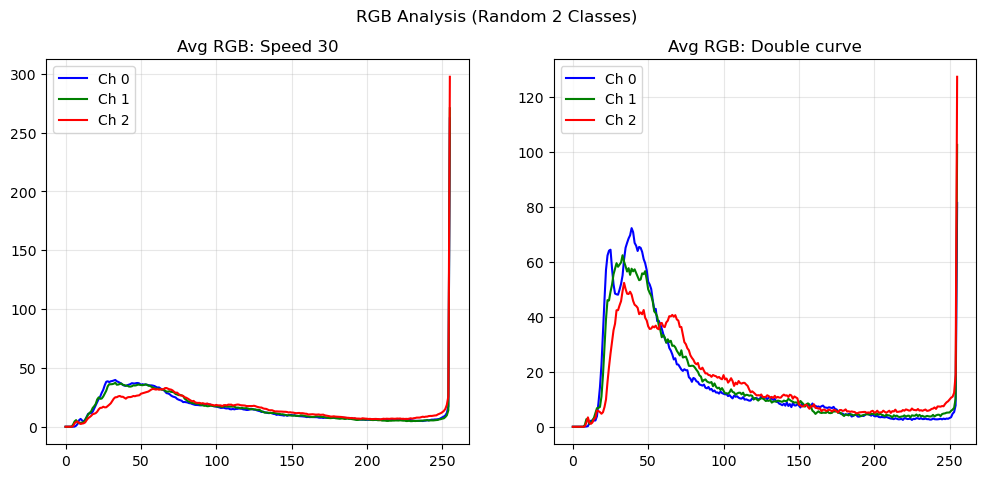


[INFO] 4. Visualizing SIFT Keypoints...


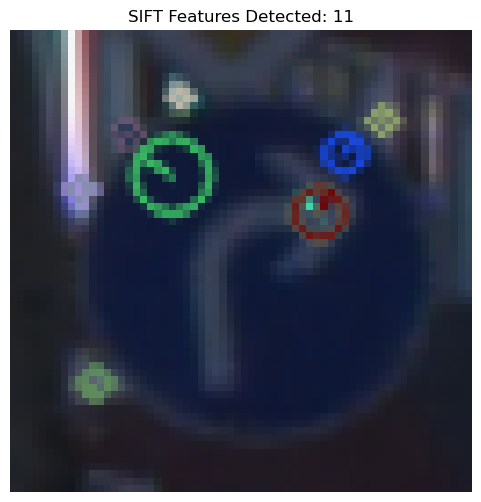

[TIME] Color Hist Extraction: 0.1457s
[INFO] BoW: Building vocabulary...
[INFO] BoW: Vocabulary created.
[TIME] SIFT BoW Pipeline: 18.5268s


In [ ]:

# FINAL!!!!
# # A. SELECT DATASET ("GTSRB" or "CIFAR")
DATASET_CHOICE = "GTSRB" 
SAMPLE_FRAC = 0.2
if DATASET_CHOICE == "GTSRB":
    train_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images"
    test_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Test_Images\GTSRB\Final_Test\Images"
    
    X_train, y_train = load_gtsrb_data(train_path, mode="train", sample_fraction=SAMPLE_FRAC)
    X_test, y_test = load_gtsrb_data(test_path, mode="test", sample_fraction=SAMPLE_FRAC)
    
    classes = GTSRB_CLASSES
    # Visualization subset
    X_viz = X_train[:5] if len(X_train) > 0 else []
    y_viz = y_train[:5] if len(y_train) > 0 else []

else:
    # CIFAR-10 Logic
    X_all, y_all = load_cifar_adapter(sample_fraction=SAMPLE_FRAC) 
    classes = CIFAR_CLASSES
    X_viz, y_viz = X_all, y_all
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)


print(f"\n[INFO] Dataset Stats:")
print(f"   Training Images: {len(X_train)}")
print(f"   Testing Images:  {len(X_test)}")


# B. DATA EXPLORATION
print("\n[INFO] 1. Plotting Data Samples...")
plot_samples(X_viz, y_viz, classes)
print("\n[INFO] 2. Plotting Class Distribution (Train)...")
plot_class_distribution(y_train, classes)
print("\n[INFO] 3. Plotting RGB Histograms...")
plot_rgb_histograms_dynamic(X_train, y_train, classes)
print("\n[INFO] 4. Visualizing SIFT Keypoints...")
if len(X_train) > 0: visualize_sift_keypoints(X_train[np.random.randint(len(X_train))])


# D. PREPARE FEATURES
# 1. Color Histograms
start = time.time()
X_train_hist = extract_color_histograms(X_train)
X_test_hist = extract_color_histograms(X_test)
time_feat_hist = time.time() - start
print(f"[TIME] Color Hist Extraction: {time_feat_hist:.4f}s")

# 2. SIFT Bag-of-Words (Fit ONLY on Train)
start_sift = time.time()
bow = VisualBagOfWords(k=VOCAB_SIZE)
bow.fit(X_train) 
X_train_bow = bow.transform(X_train)
X_test_bow = bow.transform(X_test)
time_feat_sift = time.time() - start_sift
print(f"[TIME] SIFT BoW Pipeline: {time_feat_sift:.4f}s")


In [64]:
models_store = {}
performance_log = []

param_grid_svm = {
        'C': [0.1, 1, 10, 100], 
        'gamma': ['scale', 0.1, 0.01] 
    }
param_grid_rf = {
        'n_estimators': [10, 50, 100],
        'max_depth': [5, 10, 20, None]
    }


[1] Hist + SVM: Tuning...
[PLOT] Generating plot for: ['C', 'gamma']


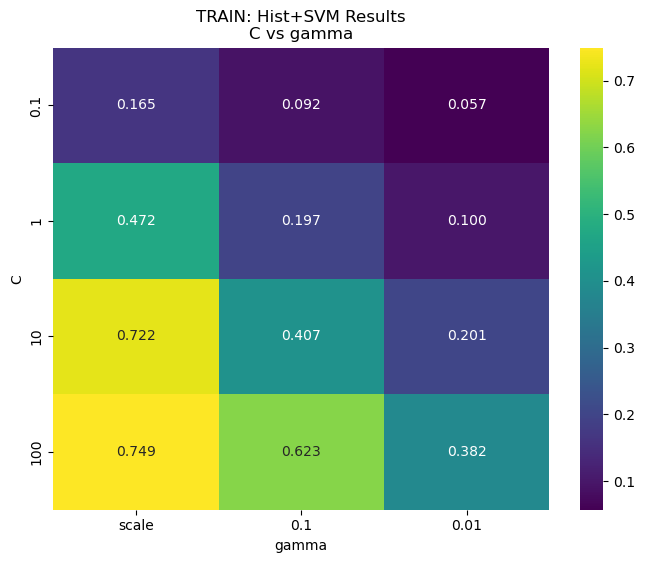

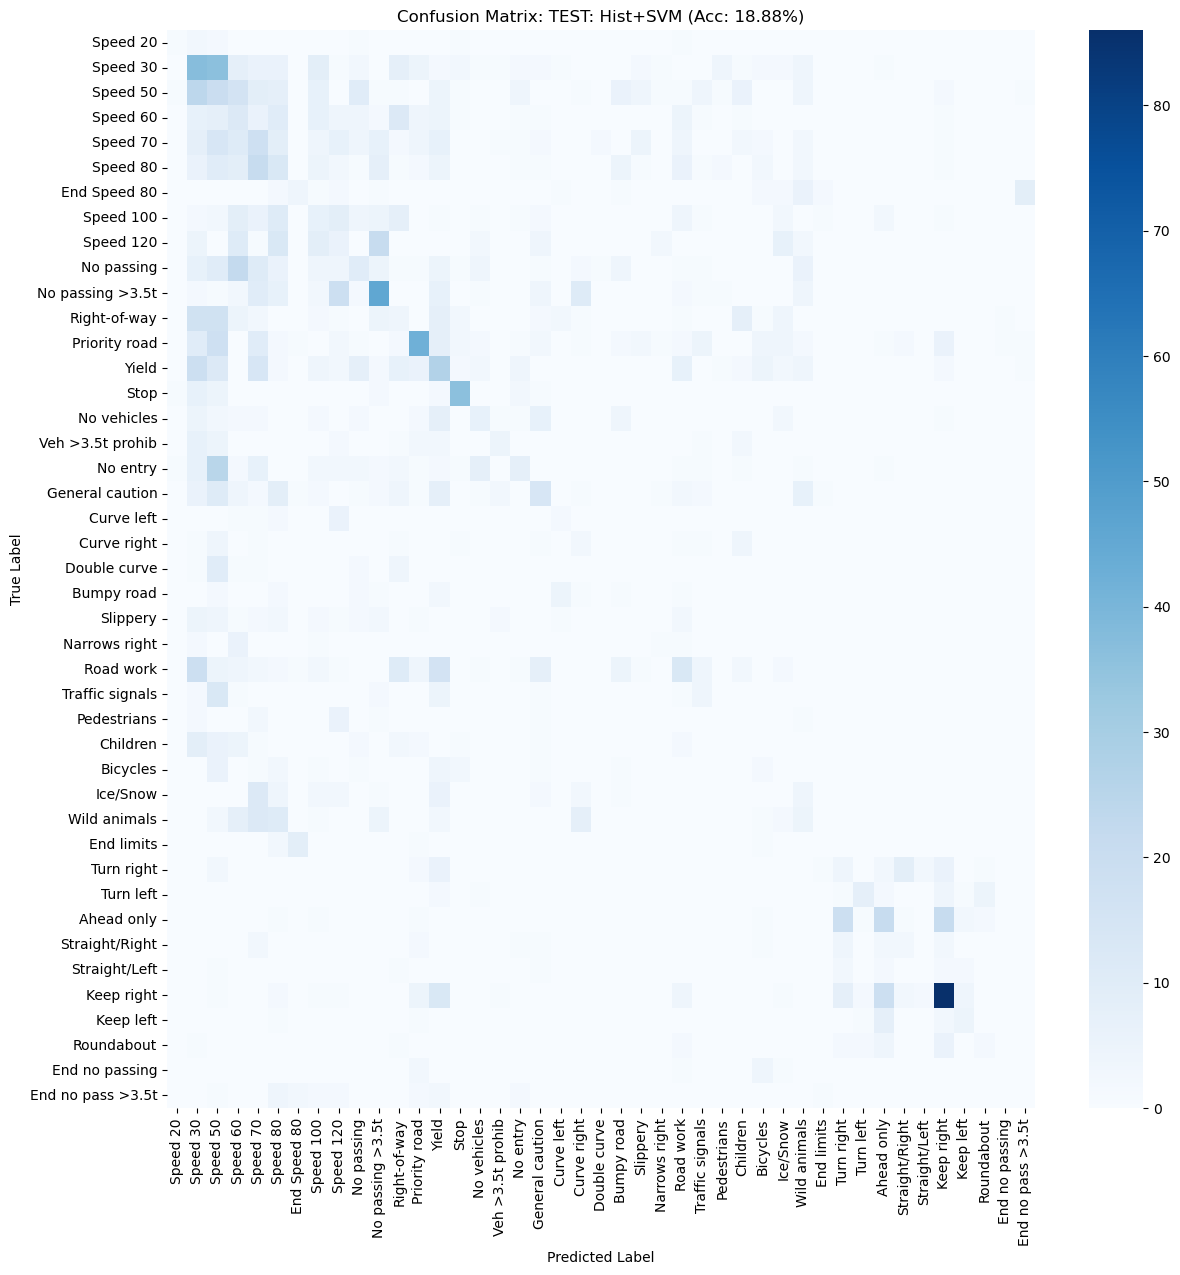

In [67]:
# E. TRAIN 4 MODELS

print("\n[1] Hist + SVM: Tuning...")
start = time.time()
svm_h = GridSearchCV(SVC(probability=True), param_grid_svm, cv=3, n_jobs=-1)
svm_h.fit(X_train_hist, y_train)
time_train = time.time() - start

start = time.time()
acc = svm_h.score(X_test_hist, y_test)
time_test = time.time() - start

models_store['Hist_SVM'] = svm_h
plot_grid_results(svm_h, title="TRAIN: Hist+SVM Results")
plot_confusion_matrix_dynamic(y_test, svm_h.predict(X_test_hist), f"TEST: Hist+SVM (Acc: {acc:.2%})", classes)

performance_log.append({
    "Model": "Hist + SVM", "Feat Time (s)": f"{time_feat_hist:.2f}",
    "Train Time (s)": f"{time_train:.2f}", "Test Time (s)": f"{time_test:.4f}",
    "Accuracy": f"{acc:.4f}", "Best Params": str(svm_h.best_params_)
})



[2] Hist + RF: Tuning...
[PLOT] Generating plot for: ['n_estimators', 'max_depth']


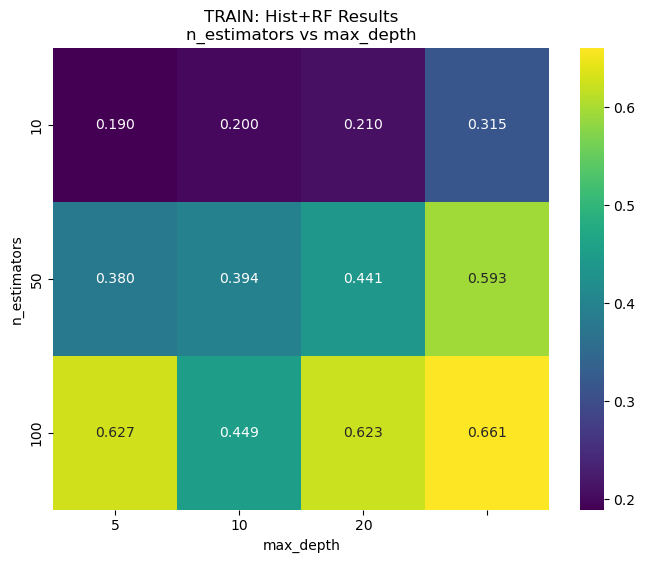

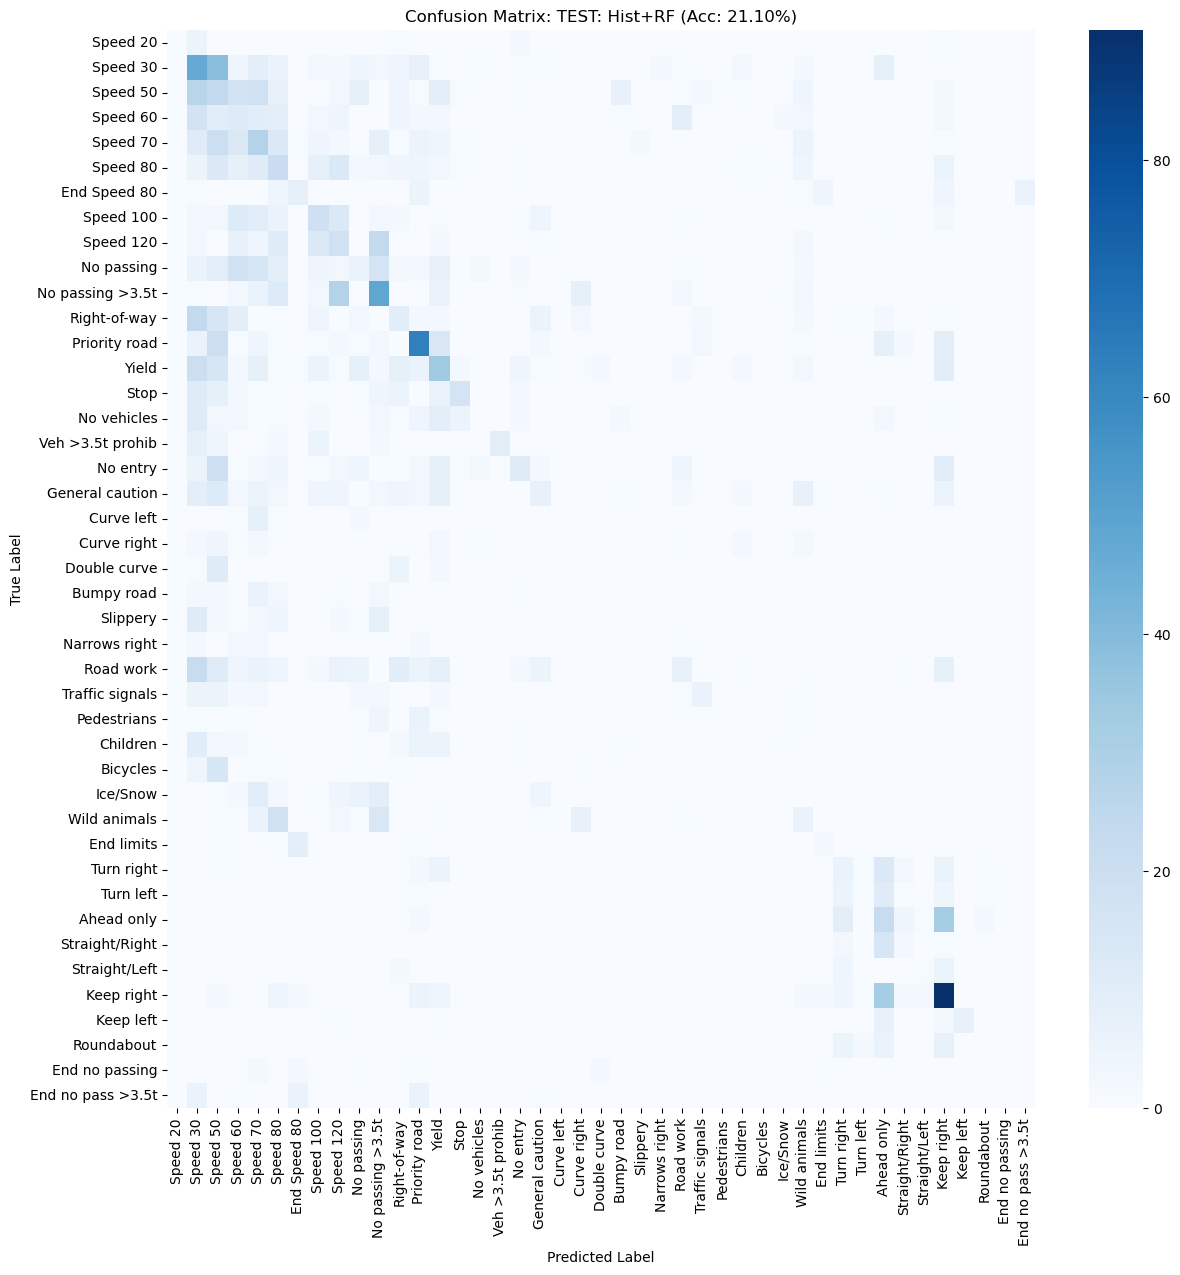

In [66]:
# --- 2. Hist + RF ---
print("\n[2] Hist + RF: Tuning...")
start = time.time()
rf_h = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf, cv=3, n_jobs=-1)
rf_h.fit(X_train_hist, y_train)
time_train = time.time() - start

start = time.time()
acc = rf_h.score(X_test_hist, y_test)
time_test = time.time() - start

models_store['Hist_RF'] = rf_h
plot_grid_results(rf_h, title="TRAIN: Hist+RF Results")
plot_confusion_matrix_dynamic(y_test, rf_h.predict(X_test_hist), f"TEST: Hist+RF (Acc: {acc:.2%})", classes)

performance_log.append({
    "Model": "Hist + RF", "Feat Time (s)": f"{time_feat_hist:.2f}",
    "Train Time (s)": f"{time_train:.2f}", "Test Time (s)": f"{time_test:.4f}",
    "Accuracy": f"{acc:.4f}", "Best Params": str(rf_h.best_params_)
})


[3] SIFT + SVM: Tuning...
[PLOT] Generating plot for: ['C', 'gamma']


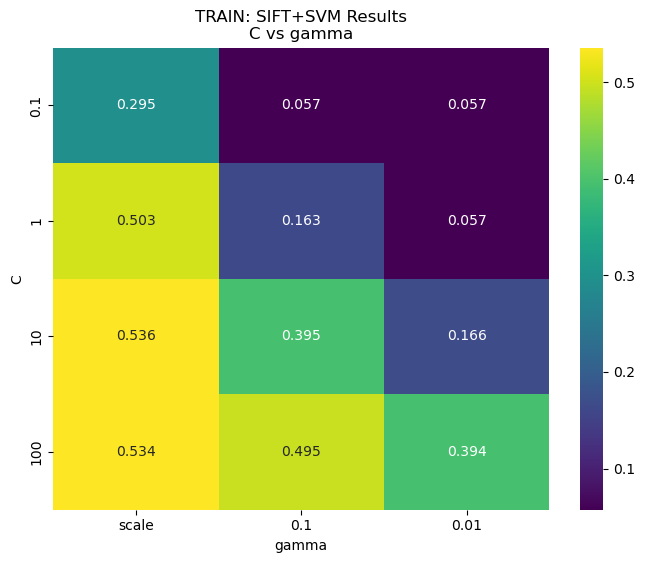

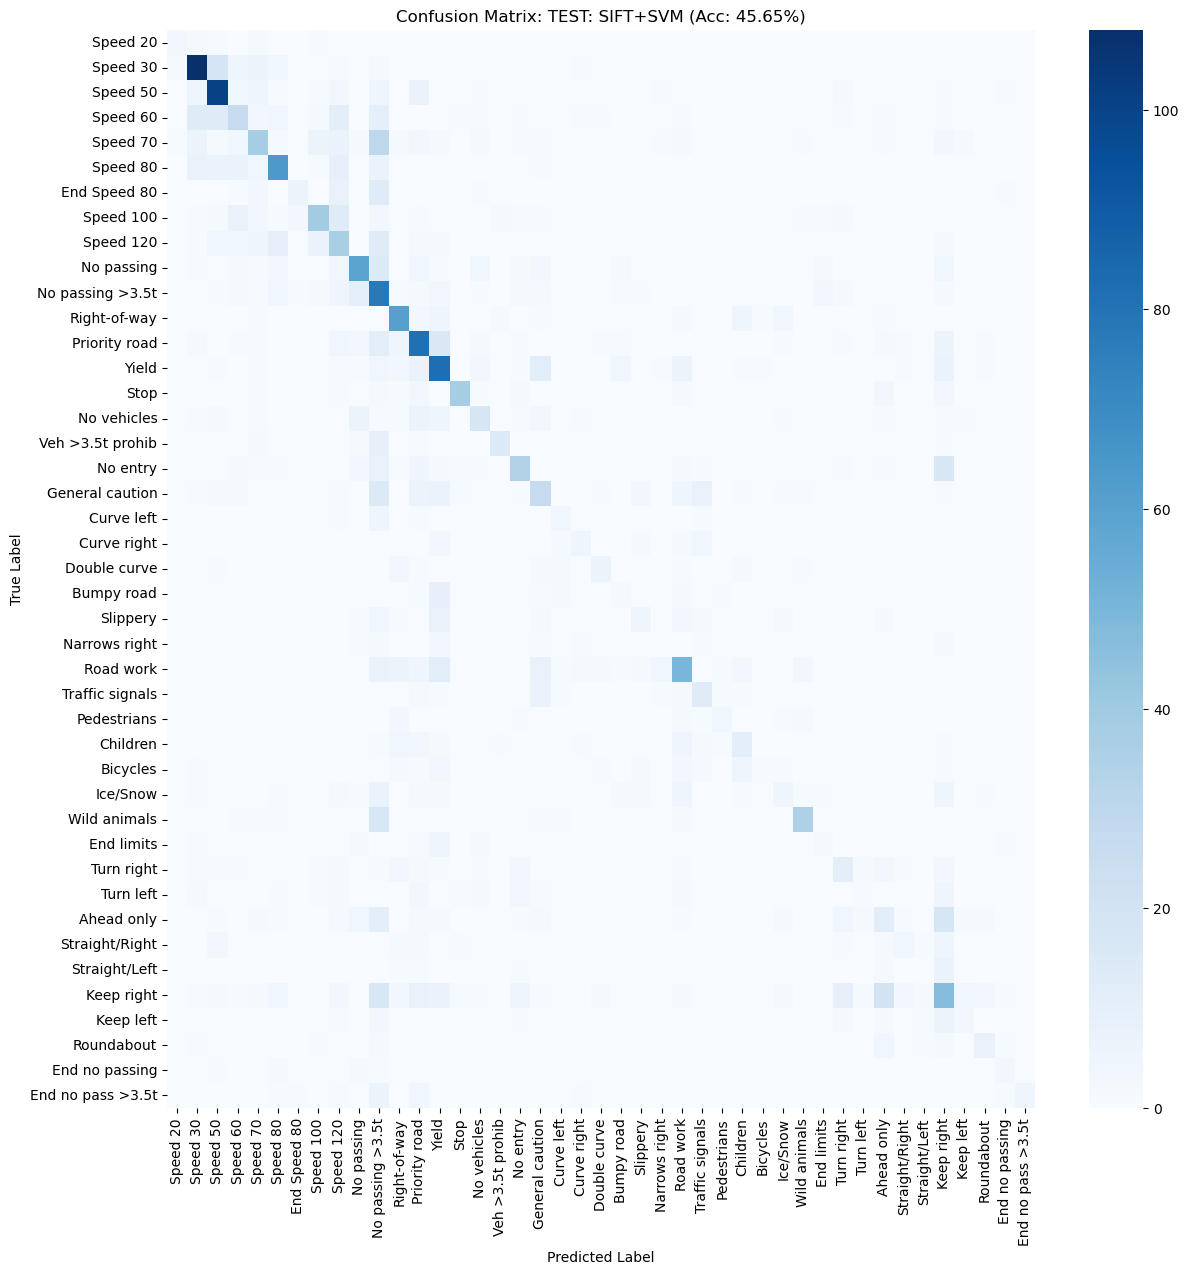

In [68]:
# --- 3. SIFT + SVM ---
print("\n[3] SIFT + SVM: Tuning...")
start = time.time()
svm_s = GridSearchCV(SVC(probability=True), param_grid_svm, cv=3, n_jobs=-1)
svm_s.fit(X_train_bow, y_train)
time_train = time.time() - start

start = time.time()
acc = svm_s.score(X_test_bow, y_test)
time_test = time.time() - start

models_store['SIFT_SVM'] = svm_s
plot_grid_results(svm_s, title="TRAIN: SIFT+SVM Results")
plot_confusion_matrix_dynamic(y_test, svm_s.predict(X_test_bow), f"TEST: SIFT+SVM (Acc: {acc:.2%})", classes)

performance_log.append({
    "Model": "SIFT + SVM", "Feat Time (s)": f"{time_feat_sift:.2f}",
    "Train Time (s)": f"{time_train:.2f}", "Test Time (s)": f"{time_test:.4f}",
    "Accuracy": f"{acc:.4f}", "Best Params": str(svm_s.best_params_)
})


[4] SIFT + RF: Tuning...
[PLOT] Generating plot for: ['n_estimators', 'max_depth']


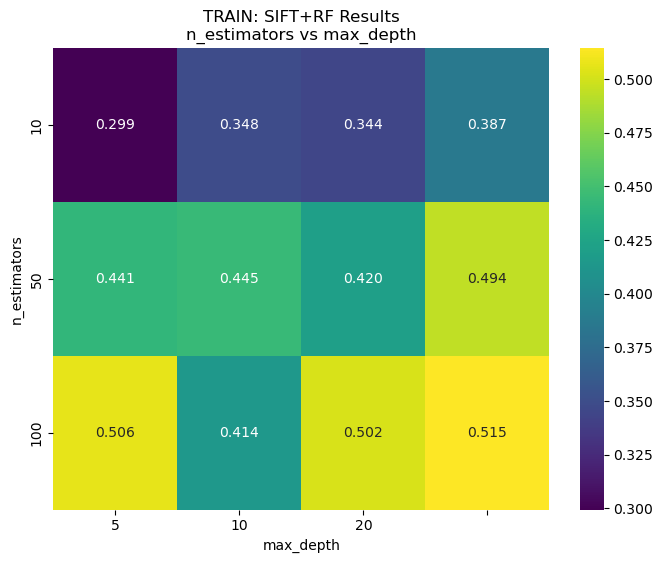

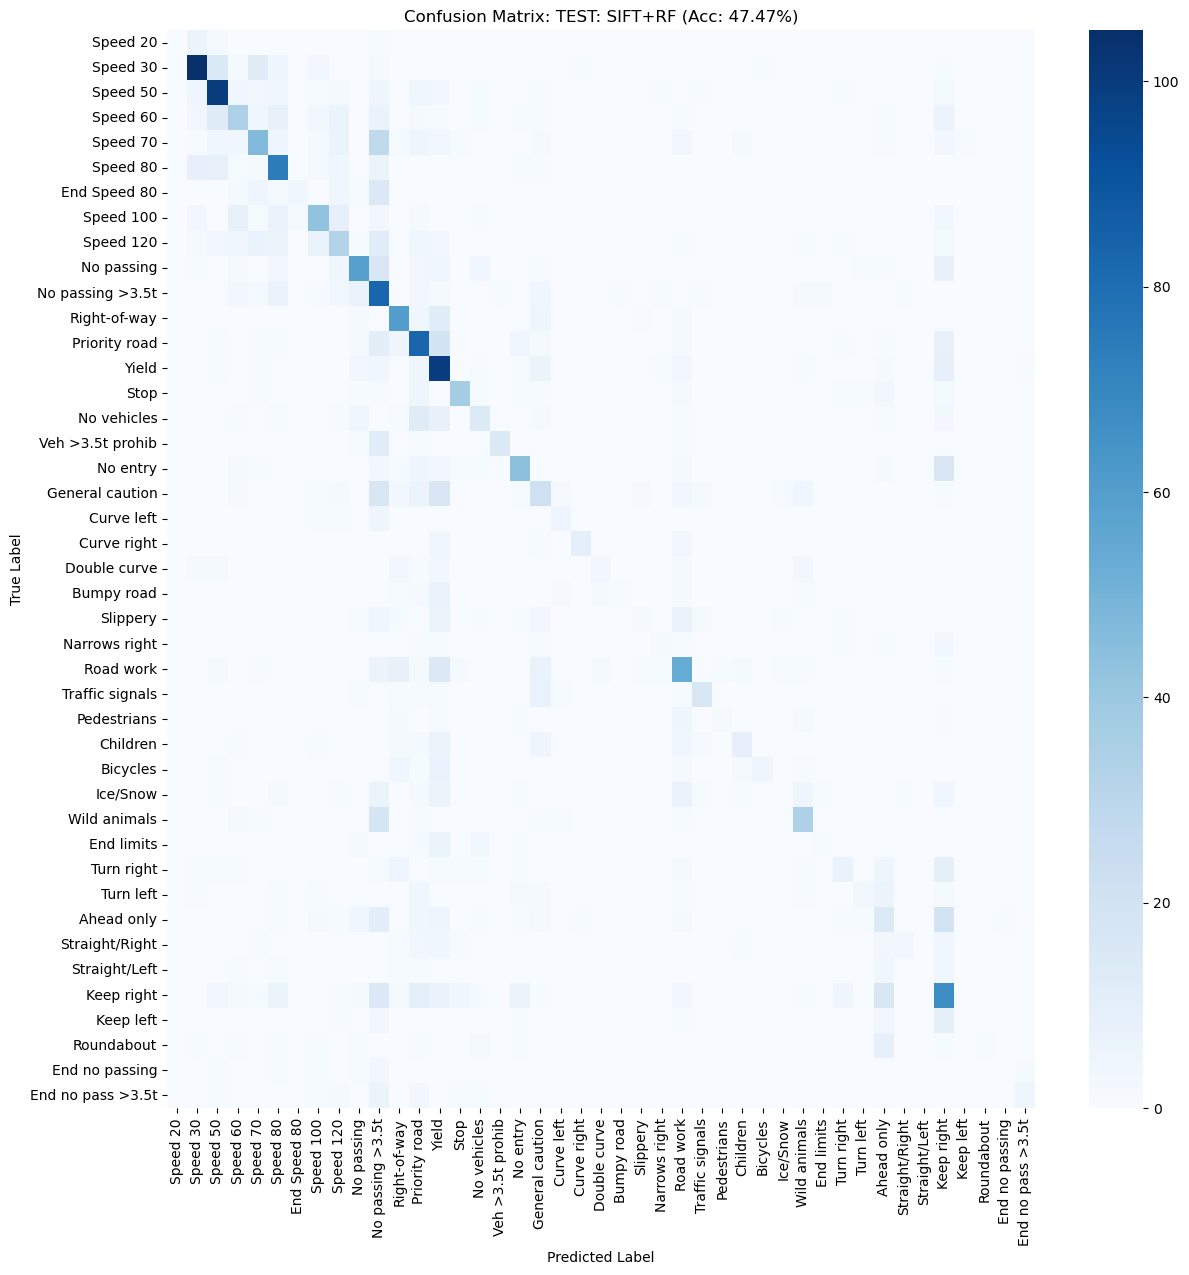

In [69]:
# --- 4. SIFT + RF ---
print("\n[4] SIFT + RF: Tuning...")
start = time.time()
rf_s = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf, cv=3, n_jobs=-1)
rf_s.fit(X_train_bow, y_train)
time_train = time.time() - start

start = time.time()
acc = rf_s.score(X_test_bow, y_test)
time_test = time.time() - start

models_store['SIFT_RF'] = rf_s
plot_grid_results(rf_s, title="TRAIN: SIFT+RF Results")
plot_confusion_matrix_dynamic(y_test, rf_s.predict(X_test_bow), f"TEST: SIFT+RF (Acc: {acc:.2%})", classes)

performance_log.append({
    "Model": "SIFT + RF", "Feat Time (s)": f"{time_feat_sift:.2f}",
    "Train Time (s)": f"{time_train:.2f}", "Test Time (s)": f"{time_test:.4f}",
    "Accuracy": f"{acc:.4f}", "Best Params": str(rf_s.best_params_)
})


FINAL PERFORMANCE SUMMARY (Sample Fraction: 0.2)
| Model      |   Feat Time (s) |   Train Time (s) |   Test Time (s) |   Accuracy | Best Params                              |
|:-----------|----------------:|-----------------:|----------------:|-----------:|:-----------------------------------------|
| Hist + RF  |            0.15 |            17.14 |          0.0436 |     0.211  | {'max_depth': None, 'n_estimators': 100} |
| Hist + SVM |            0.15 |           155.16 |          3.747  |     0.1888 | {'C': 100, 'gamma': 'scale'}             |
| SIFT + SVM |           18.53 |            54.73 |          1.6343 |     0.4565 | {'C': 10, 'gamma': 'scale'}              |
| SIFT + RF  |           18.53 |             4.81 |          0.0398 |     0.4747 | {'max_depth': None, 'n_estimators': 100} |

[INFO] Generating Detailed Classification Reports...

FINAL REPORT: Hist + SVM
Overall Accuracy: 0.1888

Per-class Accuracy:
               Speed 20: 0.111
               Speed 30: 0.250
      

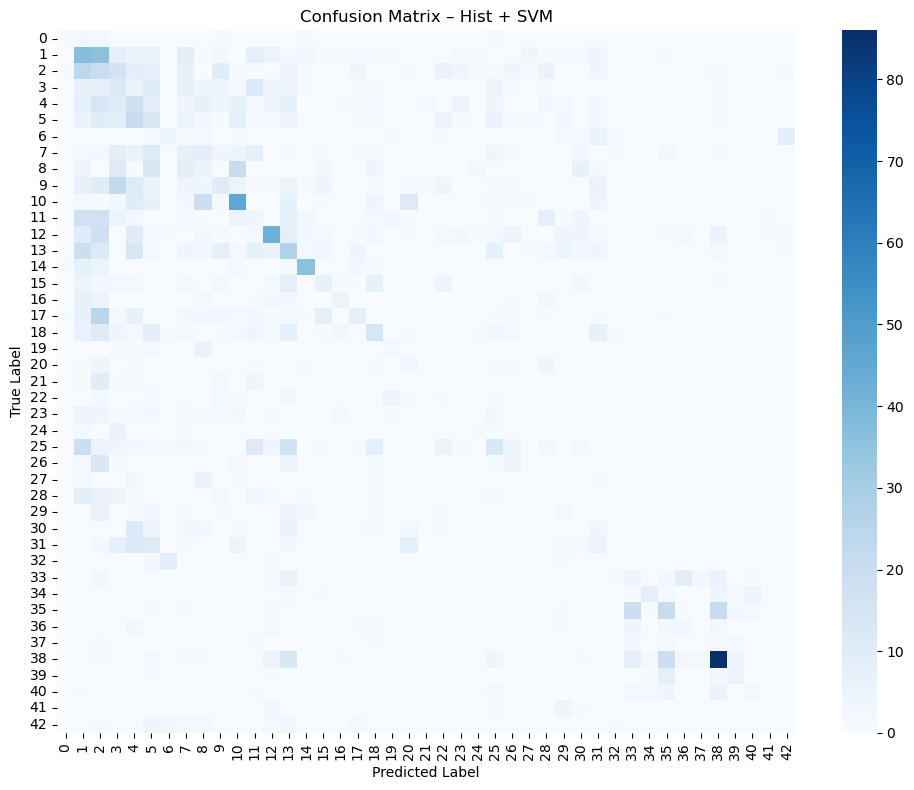


FINAL REPORT: Hist + RF
Overall Accuracy: 0.2110

Per-class Accuracy:
               Speed 20: 0.000
               Speed 30: 0.318
               Speed 50: 0.174
               Speed 60: 0.130
               Speed 70: 0.235
               Speed 80: 0.194
           End Speed 80: 0.242
              Speed 100: 0.232
              Speed 120: 0.209
             No passing: 0.056
       No passing >3.5t: 0.395
           Right-of-way: 0.116
          Priority road: 0.447
                  Yield: 0.246
                   Stop: 0.281
            No vehicles: 0.000
       Veh >3.5t prohib: 0.300
               No entry: 0.136
        General caution: 0.083
             Curve left: 0.000
            Curve right: 0.000
           Double curve: 0.000
             Bumpy road: 0.000
               Slippery: 0.000
          Narrows right: 0.000
              Road work: 0.065
        Traffic signals: 0.207
            Pedestrians: 0.000
               Children: 0.000
               Bicycles: 0.000

c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


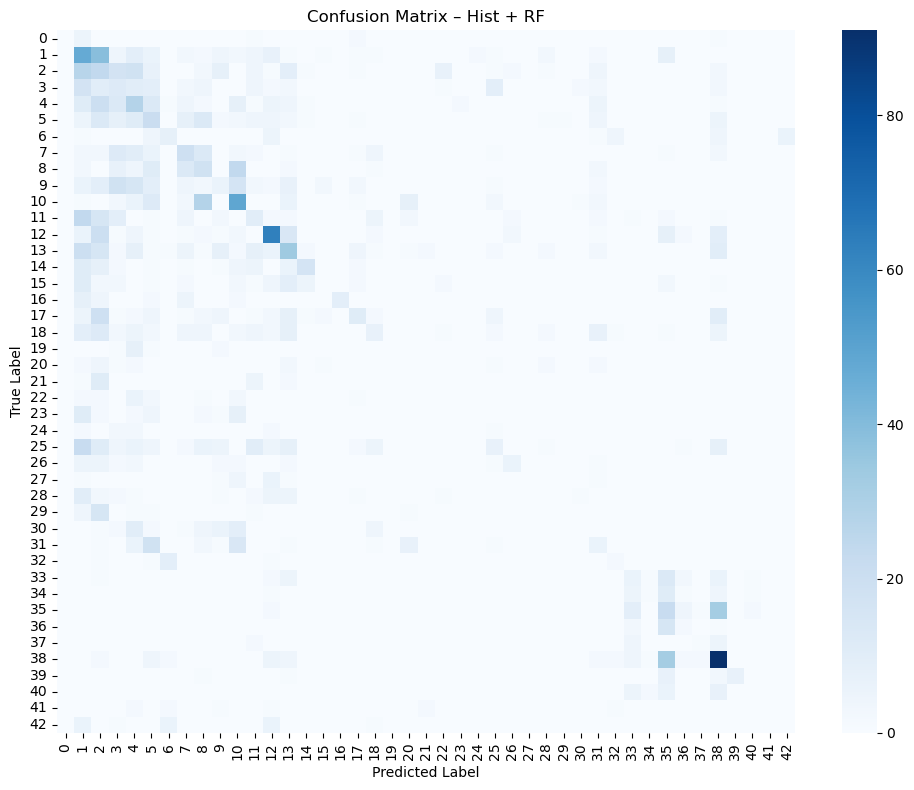


FINAL REPORT: SIFT + SVM
Overall Accuracy: 0.4565

Per-class Accuracy:
               Speed 20: 0.333
               Speed 30: 0.730
               Speed 50: 0.732
               Speed 60: 0.293
               Speed 70: 0.319
               Speed 80: 0.593
           End Speed 80: 0.182
              Speed 100: 0.476
              Speed 120: 0.430
             No passing: 0.551
       No passing >3.5t: 0.629
           Right-of-way: 0.709
          Priority road: 0.574
                  Yield: 0.594
                   Stop: 0.667
            No vehicles: 0.360
       Veh >3.5t prohib: 0.500
               No entry: 0.420
        General caution: 0.321
             Curve left: 0.333
            Curve right: 0.278
           Double curve: 0.316
             Bumpy road: 0.111
               Slippery: 0.167
          Narrows right: 0.000
              Road work: 0.467
        Traffic signals: 0.448
            Pedestrians: 0.286
               Children: 0.344
               Bicycles: 0.04

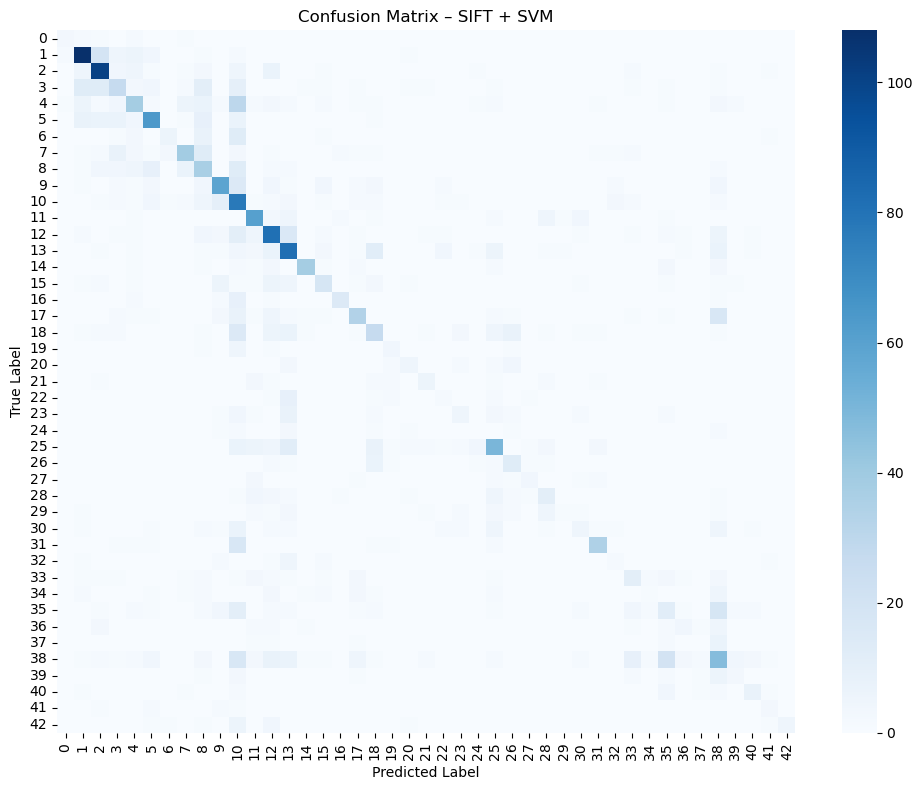


FINAL REPORT: SIFT + RF
Overall Accuracy: 0.4747

Per-class Accuracy:
               Speed 20: 0.000
               Speed 30: 0.709
               Speed 50: 0.725
               Speed 60: 0.370
               Speed 70: 0.395
               Speed 80: 0.685
           End Speed 80: 0.121
              Speed 100: 0.524
              Speed 120: 0.372
             No passing: 0.551
       No passing >3.5t: 0.669
           Right-of-way: 0.698
          Priority road: 0.589
                  Yield: 0.717
                   Stop: 0.649
            No vehicles: 0.280
       Veh >3.5t prohib: 0.500
               No entry: 0.543
        General caution: 0.262
             Curve left: 0.417
            Curve right: 0.556
           Double curve: 0.158
             Bumpy road: 0.056
               Slippery: 0.067
          Narrows right: 0.182
              Road work: 0.505
        Traffic signals: 0.552
            Pedestrians: 0.143
               Children: 0.281
               Bicycles: 0.217

c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


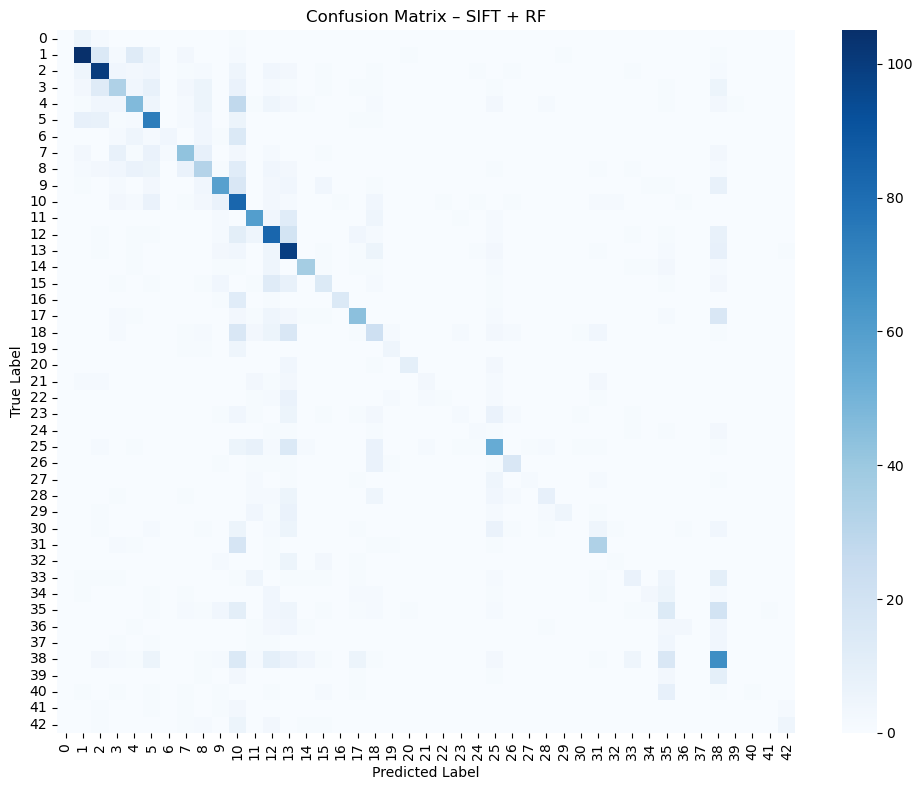


PREDICTION: temp_query.png


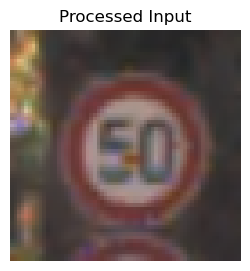


--- Hist+SVM ---
   1. No passing           : 42.45%
   2. Children             : 17.20%
   3. Speed 30             : 8.07%
   4. General caution      : 5.44%
   5. Road work            : 3.79%

--- Hist+RF ---
   1. No passing           : 20.00%
   2. Speed 50             : 13.00%
   3. Road work            : 6.00%
   4. Speed 30             : 6.00%
   5. Right-of-way         : 6.00%

--- SIFT+SVM ---
   1. Speed 50             : 84.75%
   2. Speed 60             : 9.64%
   3. Speed 30             : 2.15%
   4. Speed 70             : 0.62%
   5. Speed 120            : 0.51%

--- SIFT+RF ---
   1. Speed 50             : 60.00%
   2. Speed 60             : 12.00%
   3. Speed 30             : 12.00%
   4. Speed 100            : 6.00%
   5. Road work            : 3.00%


In [70]:
# F. FINAL SUMMARY
print("\n" + "="*60)
print(f"FINAL PERFORMANCE SUMMARY (Sample Fraction: {SAMPLE_FRAC})")
print("="*60)
df_results = pd.DataFrame(performance_log)
try: print(df_results.to_markdown(index=False)) 
except: print(df_results)

# G. GENERATE FULL REPORTS
print("\n[INFO] Generating Detailed Classification Reports...")
variations = [("Hist + SVM", 'Hist_SVM', X_test_hist), ("Hist + RF", 'Hist_RF', X_test_hist),
                ("SIFT + SVM", 'SIFT_SVM', X_test_bow), ("SIFT + RF", 'SIFT_RF', X_test_bow)]

for title, key, X_data in variations:
    if key in models_store:
        evaluate_and_report(models_store[key], X_data, y_test, classes, title)

# H. INFERENCE DEMO
test_path = "temp_query.png"
# Pick a random test image to simulate a query
if len(X_test) > 0:
    cv2.imwrite(test_path, X_test[0]) 
    predict_from_path(test_path, models_store, bow, classes)


PREDICTION: C:\Users\lenar\Downloads\GTSRB_Final_Test_Images\GTSRB\Final_Test\Images\03767.ppm


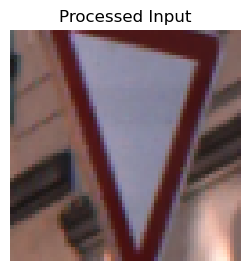


--- Hist+SVM ---
   1. Speed 30             : 21.06%
   2. No passing           : 14.08%
   3. Speed 50             : 11.78%
   4. Keep right           : 8.58%
   5. Priority road        : 8.54%

--- Hist+RF ---
   1. No passing           : 9.00%
   2. Yield                : 9.00%
   3. Speed 50             : 8.00%
   4. Right-of-way         : 7.00%
   5. Speed 70             : 6.00%

--- SIFT+SVM ---
   1. General caution      : 38.79%
   2. Yield                : 11.74%
   3. Road work            : 7.97%
   4. Children             : 5.45%
   5. Veh >3.5t prohib     : 4.37%

--- SIFT+RF ---
   1. Yield                : 17.04%
   2. General caution      : 10.02%
   3. No vehicles          : 7.00%
   4. Road work            : 5.04%
   5. Wild animals         : 5.04%


In [71]:
trial_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Test_Images\GTSRB\Final_Test\Images\03767.ppm"#"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images\00017\00034_00015.ppm"#"C:\Users\lenar\Downloads\Screenshot 2026-01-18 143736.png"
predict_from_path(trial_path, models_store, bow, classes)